# SOC workbench with k-space bright/dark/phonon Hamiltonian
#

This copy keeps the finite spin-chain calculation for delta and C1, then builds a k-resolved projected optical Hamiltonian H(k).


In [74]:
from pathlib import Path
from datetime import datetime
import csv
import json
import sys

import matplotlib

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "SolverV9").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate PROJECT_ROOT containing SolverV8.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from SolverV9 import (
    LiouvilleSpectroscopySolver,
    SpectroscopyPlotter,
    build_mechanism_note,
    extract_spectrum_observables,
    extract_spectrum_profile,
    make_run_id,
    save_spectrum_bundle,
    standard_nq_protocol,
)

RESULT_ROOT = PROJECT_ROOT / "SOC Model" / "result_3_0_k_model"
CODE_DIR = RESULT_ROOT / "code"
DATA_DIR = RESULT_ROOT / "Data"
FIGURES_DIR = RESULT_ROOT / "Figures"
ANALYSIS_DIR = RESULT_ROOT / "Analysis"
REPORT_DIR = RESULT_ROOT / "report"
SOURCE_NOTEBOOK = (
    PROJECT_ROOT
    / "SOC Model"
    / "Result_Test"
    / "etape_3"
    / "step3_dynamic_dimerisation_phonon.ipynb"
)

for directory in (CODE_DIR, DATA_DIR, FIGURES_DIR, ANALYSIS_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)


## Parameters and scan definitions



In [75]:
K_B_EV_K = 8.617333262145e-5
MU_B_EV_T = 5.7883818060e-5
matched_lambda_C = 0.01 / -0.443

model_params = {
    "Delta_dark": 0.90,
    "Delta_Bright": 1.00,
    "mu_B": 1.0,
    "mu_D": 0.0,
    "V0": 0.1,
    "lambda_delta": 0.00,
    "lambda_C": 0.00,
    "delta_source": "spin_peierls_mean_field",
    "delta_external": 0.0,
    "C1": 0.0,
    "spin_correlation_source": "exact_spin_chain",
    "n_bosons": 3,
    "omega_Q": 0.035,
    "g_Q": 0.007,
    "dark_hoppings_eV": [0.],
    "bright_hoppings_eV": [0.01],
    "spin_mode_dispersion_scale": 1.0,
    "bright_dark_k_modulation": 0.0,
    "g_Q_k_modulation": 0.75,
    "phonon_displacement_couples_to": "bright_dark",
    "T": 7.0,
    "T_SP_0": 14.0,
    "B": 0.0,
    "delta_0": 0.01,
    "beta": 0.5,
    "alpha_field": 0.004,
    "N_spin": 6,
    "J_spin_eV": 0.010,
    "J2_spin_eV": 0.0,
    "g_factor": 2.0,
    "boundary": "open",
    "N_k": 70,
    "gamma_orb": 0.0,
    "gamma_phonon": 0.0,
}

output_stem = "SOC_workbench_k_model"

solver_params = {
    "T": 0.0,
    "Eta": 0.005,
    "backend": "dense",
    "parallel_backend": "threading",
    "n_jobs": -1,
}

spectrum_params = {
    "N_w": 100,
    "omega1_rephasing_min": -1.35,
    "omega1_rephasing_max": -0.65,
    "omega1_unrephasing_min": 0.65,
    "omega1_unrephasing_max": 1.35,
    "omega3_min": 0.65,
    "omega3_max": 1.35,
}



## Explicit spin-chain model



In [76]:
def spin_peierls_transition_temperature(B, T_SP_0, alpha_field):
    return max(0.0, float(T_SP_0) * (1.0 - float(alpha_field) * float(B) ** 2))


def spin_peierls_delta(T, B, T_SP_0, delta_0, beta, alpha_field):
    T_SP = spin_peierls_transition_temperature(B, T_SP_0, alpha_field)
    if T_SP > 0.0 and float(T) < T_SP:
        return float(delta_0) * (1.0 - float(T) / T_SP) ** float(beta)
    return 0.0


def resolve_delta(params):
    if params["delta_source"] == "spin_peierls_mean_field":
        return spin_peierls_delta(
            params["T"],
            params["B"],
            params["T_SP_0"],
            params["delta_0"],
            params["beta"],
            params["alpha_field"],
        )
    return float(params["delta_external"])


def single_site_spin_matrices():
    sx = 0.5 * np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
    sy = 0.5 * np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex)
    sz = 0.5 * np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    return sx, sy, sz


def kron_all(operators):
    out = np.array([[1.0]], dtype=complex)
    for op in operators:
        out = np.kron(out, op)
    return out


def spin_site_operators(N_spin):
    sx, sy, sz = single_site_spin_matrices()
    ident = np.eye(2, dtype=complex)
    site_ops = []
    for site in range(N_spin):
        ops = []
        for alpha in (sx, sy, sz):
            factors = [ident] * N_spin
            factors[site] = alpha
            ops.append(kron_all(factors))
        site_ops.append(tuple(ops))
    return site_ops


def spin_dot_operator(site_ops, i, j):
    return sum(site_ops[i][axis] @ site_ops[j][axis] for axis in range(3))


def nearest_neighbor_pairs(N_spin, boundary):
    pairs = [(i, i + 1) for i in range(N_spin - 1)]
    if boundary == "periodic" and N_spin > 2:
        pairs.append((N_spin - 1, 0))
    return pairs


def next_nearest_neighbor_pairs(N_spin, boundary):
    pairs = [(i, i + 2) for i in range(N_spin - 2)]
    if boundary == "periodic" and N_spin > 3:
        pairs.extend([(N_spin - 2, 0), (N_spin - 1, 1)])
    return pairs


def build_spin_hamiltonian(params, delta):
    N_spin = int(params["N_spin"])
    boundary = str(params["boundary"])
    dim = 2**N_spin
    site_ops = spin_site_operators(N_spin)
    H = np.zeros((dim, dim), dtype=complex)
    bond_ops = []

    for i, j in nearest_neighbor_pairs(N_spin, boundary):
        bond = spin_dot_operator(site_ops, i, j)
        J_i = float(params["J_spin_eV"]) * (1.0 + ((-1.0) ** i) * float(delta))
        H += J_i * bond
        bond_ops.append(bond)

    for i, j in next_nearest_neighbor_pairs(N_spin, boundary):
        H += float(params["J2_spin_eV"]) * spin_dot_operator(site_ops, i, j)

    zeeman = sum(site_ops[i][2] for i in range(N_spin))
    H += float(params["g_factor"]) * MU_B_EV_T * float(params["B"]) * zeeman
    return H, bond_ops


def thermal_expectation_from_eigensystem(evals, evecs, operator, T):
    op_eigen_diag = np.einsum("ij,ij->j", evecs.conj(), operator @ evecs)
    if float(T) <= 0.0:
        e0 = float(np.min(evals))
        mask = np.isclose(evals, e0, atol=1e-12)
        return complex(np.mean(op_eigen_diag[mask]))
    beta = 1.0 / (K_B_EV_K * float(T))
    shifted = evals - float(np.min(evals))
    weights = np.exp(-beta * shifted)
    return complex(np.dot(weights, op_eigen_diag) / np.sum(weights))


def exact_spin_chain_observables(params, delta):
    H_spin, bond_ops = build_spin_hamiltonian(params, delta)
    hermitian_residual = float(np.max(np.abs(H_spin - H_spin.conj().T)))
    evals, evecs = np.linalg.eigh(H_spin)
    bond_values = [
        thermal_expectation_from_eigensystem(evals, evecs, op, params["T"]).real
        for op in bond_ops
    ]
    return {
        "C1": float(np.mean(bond_values)),
        "bond_C1_values": np.array(bond_values),
        "spin_dimension": int(H_spin.shape[0]),
        "spin_hilbert_dimension_expected": int(2 ** int(params["N_spin"])),
        "spin_hermitian_residual": hermitian_residual,
        "spin_ground_energy_eV": float(evals[0]),
        "spin_gap_eV": float(evals[1] - evals[0]) if len(evals) > 1 else 0.0,
    }



## k-space projected optical bright/dark/phonon model


In [77]:
def static_bright_dark_mixing(params, delta, C1):
    return (
        float(params["V0"])
        + float(params["lambda_delta"]) * float(delta)
        + float(params["lambda_C"]) * float(C1)
    )


def lowering_operator(n):
    op = np.zeros((n, n), dtype=complex)
    for upper in range(1, n):
        op[upper - 1, upper] = np.sqrt(upper)
    return op


def resolve_k_grid(N_k):
    N_k = int(N_k)
    if N_k < 1:
        raise ValueError("N_k must be >= 1")
    if N_k == 1:
        return np.array([0.0]), np.ones(1)
    k_array = np.linspace(-np.pi, np.pi, N_k, endpoint=False)
    k_weights = np.ones(N_k) / N_k
    return k_array, k_weights


def finite_neighbor_dispersion(k, onsite_energy, hoppings):
    energy = float(onsite_energy)
    for neighbor, hopping in enumerate(hoppings, start=1):
        energy += 2.0 * float(hopping) * np.cos(neighbor * float(k))
    return energy


def spin_peierls_mode_dispersion(k, params, delta):
    J = abs(float(params["J_spin_eV"]))
    if J == 0.0:
        return 0.0
    gap = 2.0 * J * float(delta) ** (2.0 / 3.0) if float(delta) > 0.0 else 0.0
    velocity = np.pi * J / 2.0
    return float(np.sqrt(gap**2 + (velocity * np.sin(float(k))) ** 2))


def build_k_space_projected_model(params):
    N_k = int(params["N_k"])
    k_array, k_weights = resolve_k_grid(N_k)

    delta = resolve_delta(params)
    spin_observables = exact_spin_chain_observables(params, delta)
    if params["spin_correlation_source"] == "exact_spin_chain":
        C1 = spin_observables["C1"]
    else:
        C1 = float(params["C1"])
    V_BD_static = static_bright_dark_mixing(params, delta, C1)

    n_bosons = int(params["n_bosons"])
    ket_g, ket_d, ket_b = 0, 1, 2

    L_bd = np.zeros((3, 3), dtype=complex)
    L_bd[ket_d, ket_b] = 1.0
    L_bd[ket_b, ket_d] = 1.0

    mu_orb = np.zeros((3, 3), dtype=complex)
    mu_orb[ket_g, ket_b] = params["mu_B"]
    mu_orb[ket_b, ket_g] = params["mu_B"]
    mu_orb[ket_g, ket_d] = params["mu_D"]
    mu_orb[ket_d, ket_g] = params["mu_D"]

    a = lowering_operator(n_bosons)
    adag = a.conj().T
    n_op = adag @ a
    q_op = a + adag

    I_orb = np.eye(3, dtype=complex)
    I_ph = np.eye(n_bosons, dtype=complex)
    dim = 3 * n_bosons

    H_stack = np.zeros((N_k, dim, dim), dtype=complex)
    mu_stack = np.zeros_like(H_stack)
    rho0 = np.zeros_like(H_stack)

    omega_reference = spin_peierls_mode_dispersion(0.0, params, delta)
    dark_hoppings = params.get("dark_hoppings_eV", [])
    bright_hoppings = params.get("bright_hoppings_eV", [])
    spin_mode_scale = float(params.get("spin_mode_dispersion_scale", 1.0))
    bd_k_modulation = float(params.get("bright_dark_k_modulation", 0.0))
    g_q_k_modulation = float(params.get("g_Q_k_modulation", 0.0))

    omega_Q_k = np.zeros(N_k, dtype=float)
    Delta_dark_k = np.zeros(N_k, dtype=float)
    Delta_Bright_k = np.zeros(N_k, dtype=float)
    V_BD_k = np.zeros(N_k, dtype=float)
    g_Q_k = np.zeros(N_k, dtype=float)

    for i_k, k in enumerate(k_array):
        Delta_dark_k[i_k] = finite_neighbor_dispersion(
            k, params["Delta_dark"], dark_hoppings
        )
        Delta_Bright_k[i_k] = finite_neighbor_dispersion(
            k, params["Delta_Bright"], bright_hoppings
        )
        omega_mode = spin_peierls_mode_dispersion(k, params, delta)
        omega_Q_k[i_k] = float(params["omega_Q"]) + spin_mode_scale * (
            omega_mode - omega_reference
        )
        V_BD_k[i_k] = V_BD_static + bd_k_modulation * np.sin(0.5 * k)
        g_Q_k[i_k] = float(params["g_Q"]) * (1.0 + g_q_k_modulation * np.cos(k))

        H_orb_k = np.zeros((3, 3), dtype=complex)
        H_orb_k[ket_d, ket_d] = Delta_dark_k[i_k]
        H_orb_k[ket_b, ket_b] = Delta_Bright_k[i_k]

        H_stack[i_k] = (
            np.kron(H_orb_k, I_ph)
            + omega_Q_k[i_k] * np.kron(I_orb, n_op)
            + V_BD_k[i_k] * np.kron(L_bd, I_ph)
            + g_Q_k[i_k] * np.kron(L_bd, q_op)
        )
        mu_stack[i_k] = np.kron(mu_orb, I_ph)
        rho0[i_k, 0, 0] = 1.0

    c_ops = []
    if params["gamma_phonon"]:
        c_ops.append((np.repeat(np.kron(I_orb, a)[None, :, :], N_k, axis=0), params["gamma_phonon"]))
    if params["gamma_orb"]:
        C_bg = np.zeros((3, 3), dtype=complex)
        C_bg[ket_g, ket_b] = 1.0
        C_dg = np.zeros((3, 3), dtype=complex)
        C_dg[ket_g, ket_d] = 1.0
        c_ops.append((np.repeat(np.kron(C_bg, I_ph)[None, :, :], N_k, axis=0), params["gamma_orb"]))
        c_ops.append((np.repeat(np.kron(C_dg, I_ph)[None, :, :], N_k, axis=0), params["gamma_orb"]))

    meta = {
        "k_array": k_array,
        "k_weights": k_weights,
        "T_SP": spin_peierls_transition_temperature(
            params["B"], params["T_SP_0"], params["alpha_field"]
        ),
        "delta": float(delta),
        "C1": float(C1),
        "V_BD_static": float(V_BD_static),
        "V_BD_k": V_BD_k,
        "Delta_dark_k": Delta_dark_k,
        "Delta_Bright_k": Delta_Bright_k,
        "omega_Q_k": omega_Q_k,
        "g_Q_k": g_Q_k,
        "omega_Q": float(params["omega_Q"]),
        "g_Q": float(params["g_Q"]),
        "dim": dim,
        **spin_observables,
    }
    return H_stack, mu_stack, c_ops, rho0, meta


def make_solver(params):
    H, mu, c_ops, rho0, meta = build_k_space_projected_model(params)
    solver = LiouvilleSpectroscopySolver(solver_params)
    solver.feed_model(
        H,
        mu,
        c_ops_raw=c_ops,
        initial_density_matrix=rho0,
        density_matrix_basis="site",
    )
    return solver, meta


## Solver set-up


In [78]:
#model_params["T"] = 15

solver, meta = make_solver(model_params)
print("Hilbert dimension:", meta["dim"])
print("N_k:", len(meta["k_array"]))
print("delta:", meta["delta"])
print("Hamiltonien dimensions:", solver.H_eigen.shape)
print("k range:", float(meta["k_array"][0]), float(meta["k_array"][-1]))
print("omega_Q(k) range:", float(np.min(meta["omega_Q_k"])), float(np.max(meta["omega_Q_k"])))
print("Delta_dark(k) range:", float(np.min(meta["Delta_dark_k"])), float(np.max(meta["Delta_dark_k"])))
print("Delta_Bright(k) range:", float(np.min(meta["Delta_Bright_k"])), float(np.max(meta["Delta_Bright_k"])))

--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
Hilbert dimension: 9
N_k: 70
delta: 0.007071067811865476
Hamiltonien dimensions: (70, 9, 9)
k range: -3.141592653589793 3.0518328634872276
omega_Q(k) range: 0.035 0.04997262850803242
Delta_dark(k) range: 0.9 0.9
Delta_Bright(k) range: 0.98 1.02


### Feynmann Diagram with NQ protocol

In [79]:
pathways = solver.generate_pathways_with_ufss(
    "-++",
    maximum_manifold=1,
    component="chi3_1Q",
)

protocol = standard_nq_protocol(
    order=1,
    nq_interval=1,
    detection_interval=3,
    n_interactions=3,
    nq_axis="omega_1Q",
    detection_axis="omega_emit",
)

[(pathway.name, pathway.interactions, pathway.coherence_orders) for pathway in pathways]


[('R1', ('Bu', 'Ku', 'Bd'), (-1, 0, 1)),
 ('R2', ('Bu', 'Bd', 'Ku'), (-1, 0, 1))]

### frequency grid

In [80]:
N_w = 100
omega1_rephasing = np.linspace(-1.1, -0.8, N_w)
omega1_unrephasing = np.linspace(0.8, 1.1, N_w)
omega3 = np.linspace(0.8, 1.1, N_w)
tau2 = 3
DETECTION_PHASE = np.pi / 2

print("rephasing omega1:", omega1_rephasing[0], omega1_rephasing[-1])
print("unrephasing omega1:", omega1_unrephasing[0], omega1_unrephasing[-1])
print("omega3:", omega3[0], omega3[-1])


rephasing omega1: -1.1 -0.8
unrephasing omega1: 0.8 1.1
omega3: 0.8 1.1


In [81]:
result = np.zeros(2, dtype=object)
spectrum_delays = {}
for i in range(1, 2, 1):
    delays = {
        "t2": 10 * i,
    }
    spectrum_delays[i] = dict(delays)

    result[i] = solver.generate_NQ_spectrum(
        1,
        protocol,
        axes={"omega_1Q": omega1_rephasing, "omega_emit": omega3},
        delays=delays,
        pathways=pathways,
        k_array=meta["k_array"],
        k_weights=meta["k_weights"],
    )


Calculating 2 pathway spectrum/s on a 100x100 grid with protocol 'standard_1q' using parallel=threading, n_jobs=-1.
Using dense prefix-tree pathway reuse.


## Plot spectra without saving


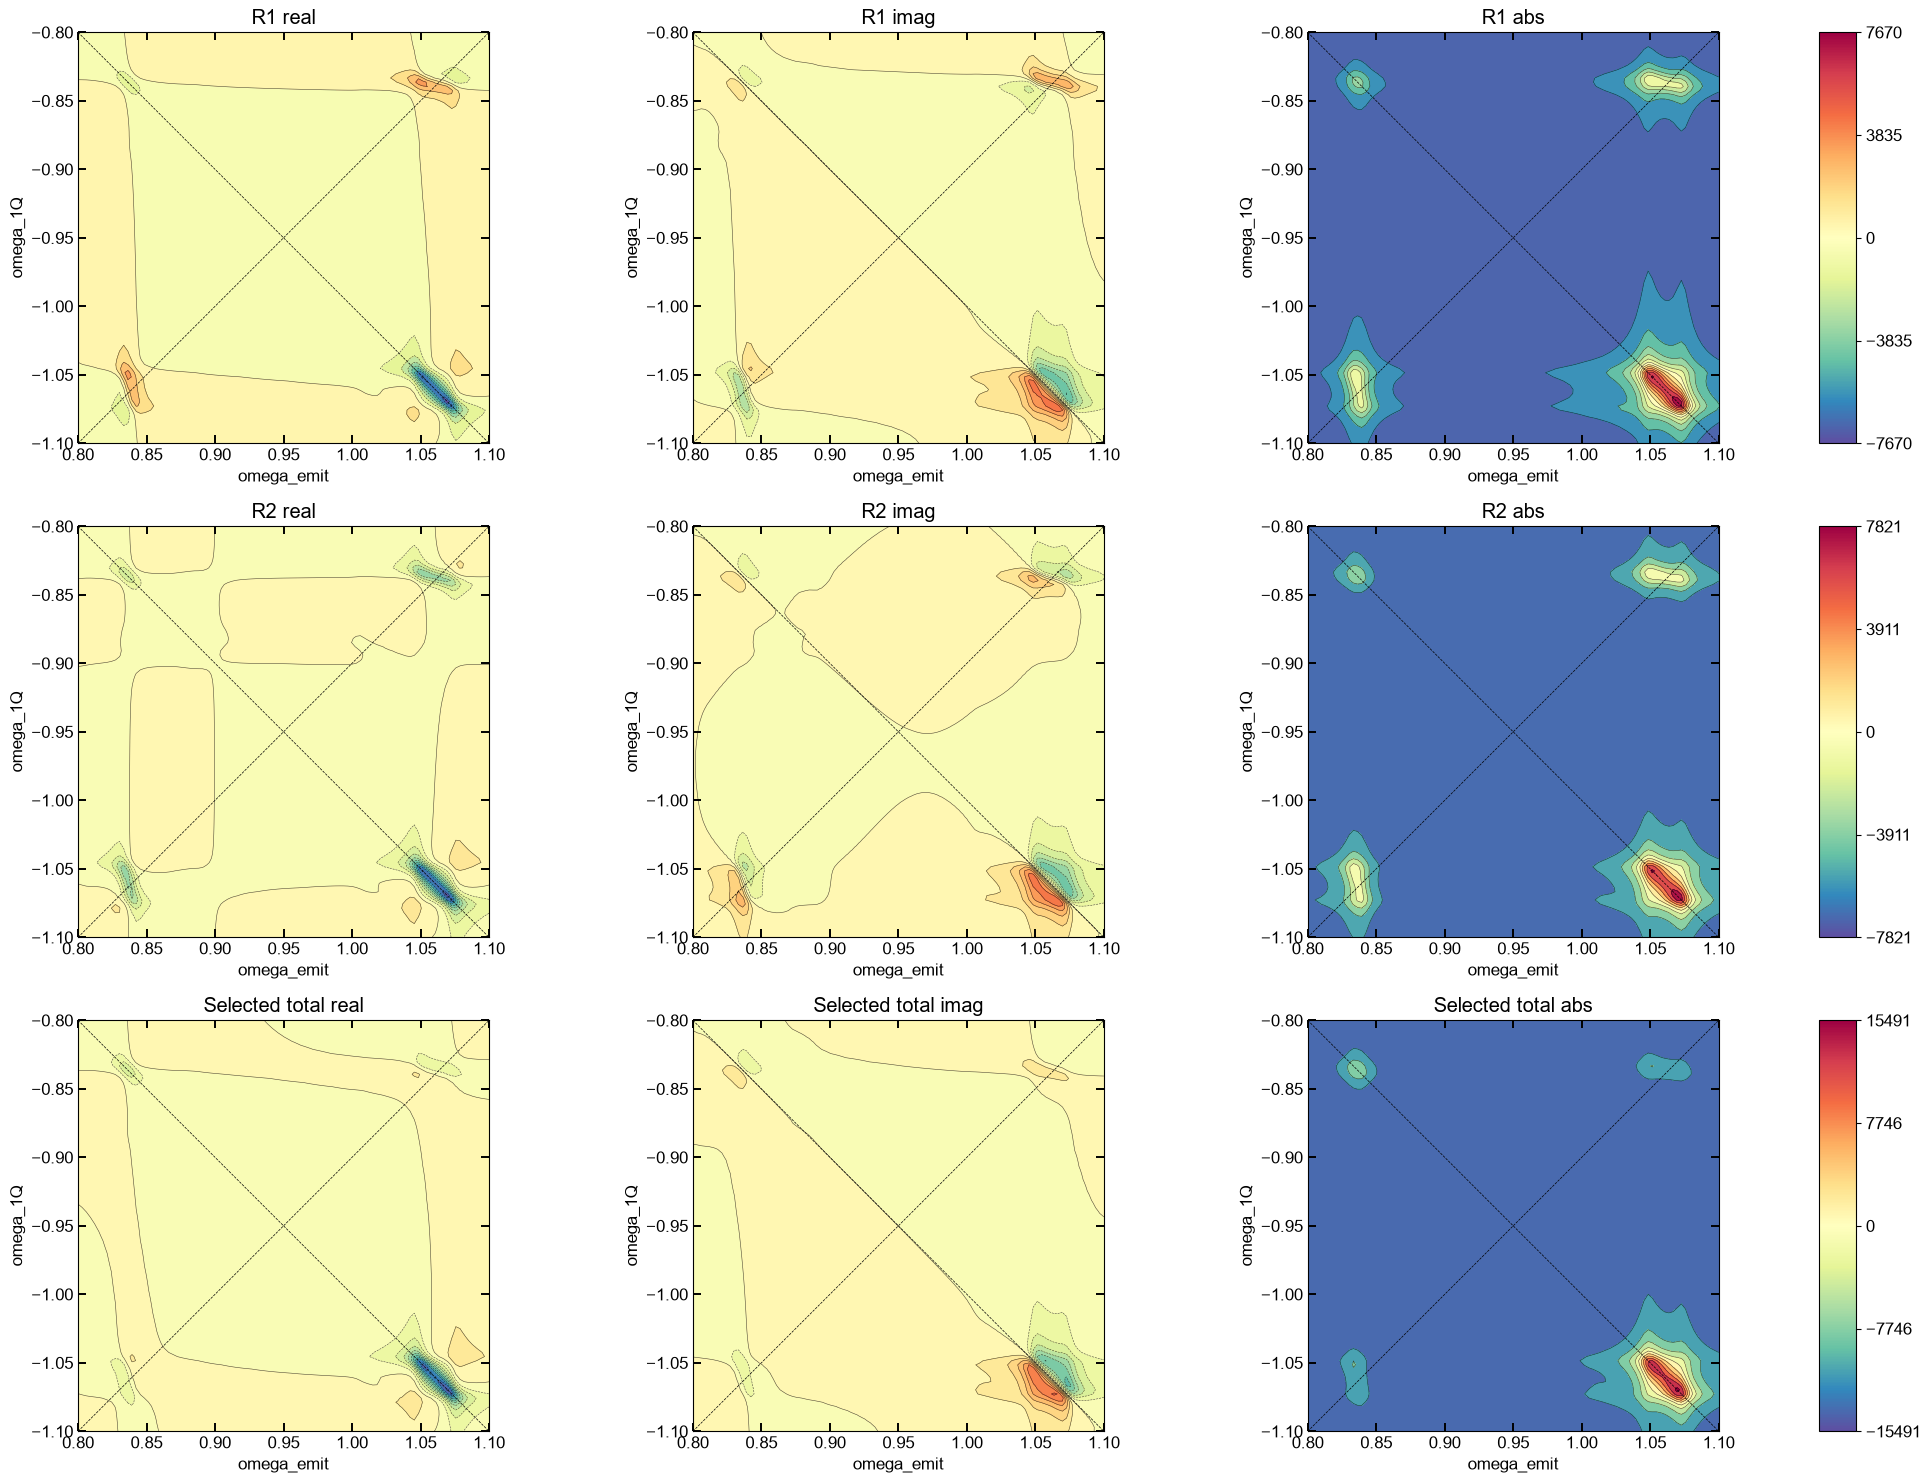

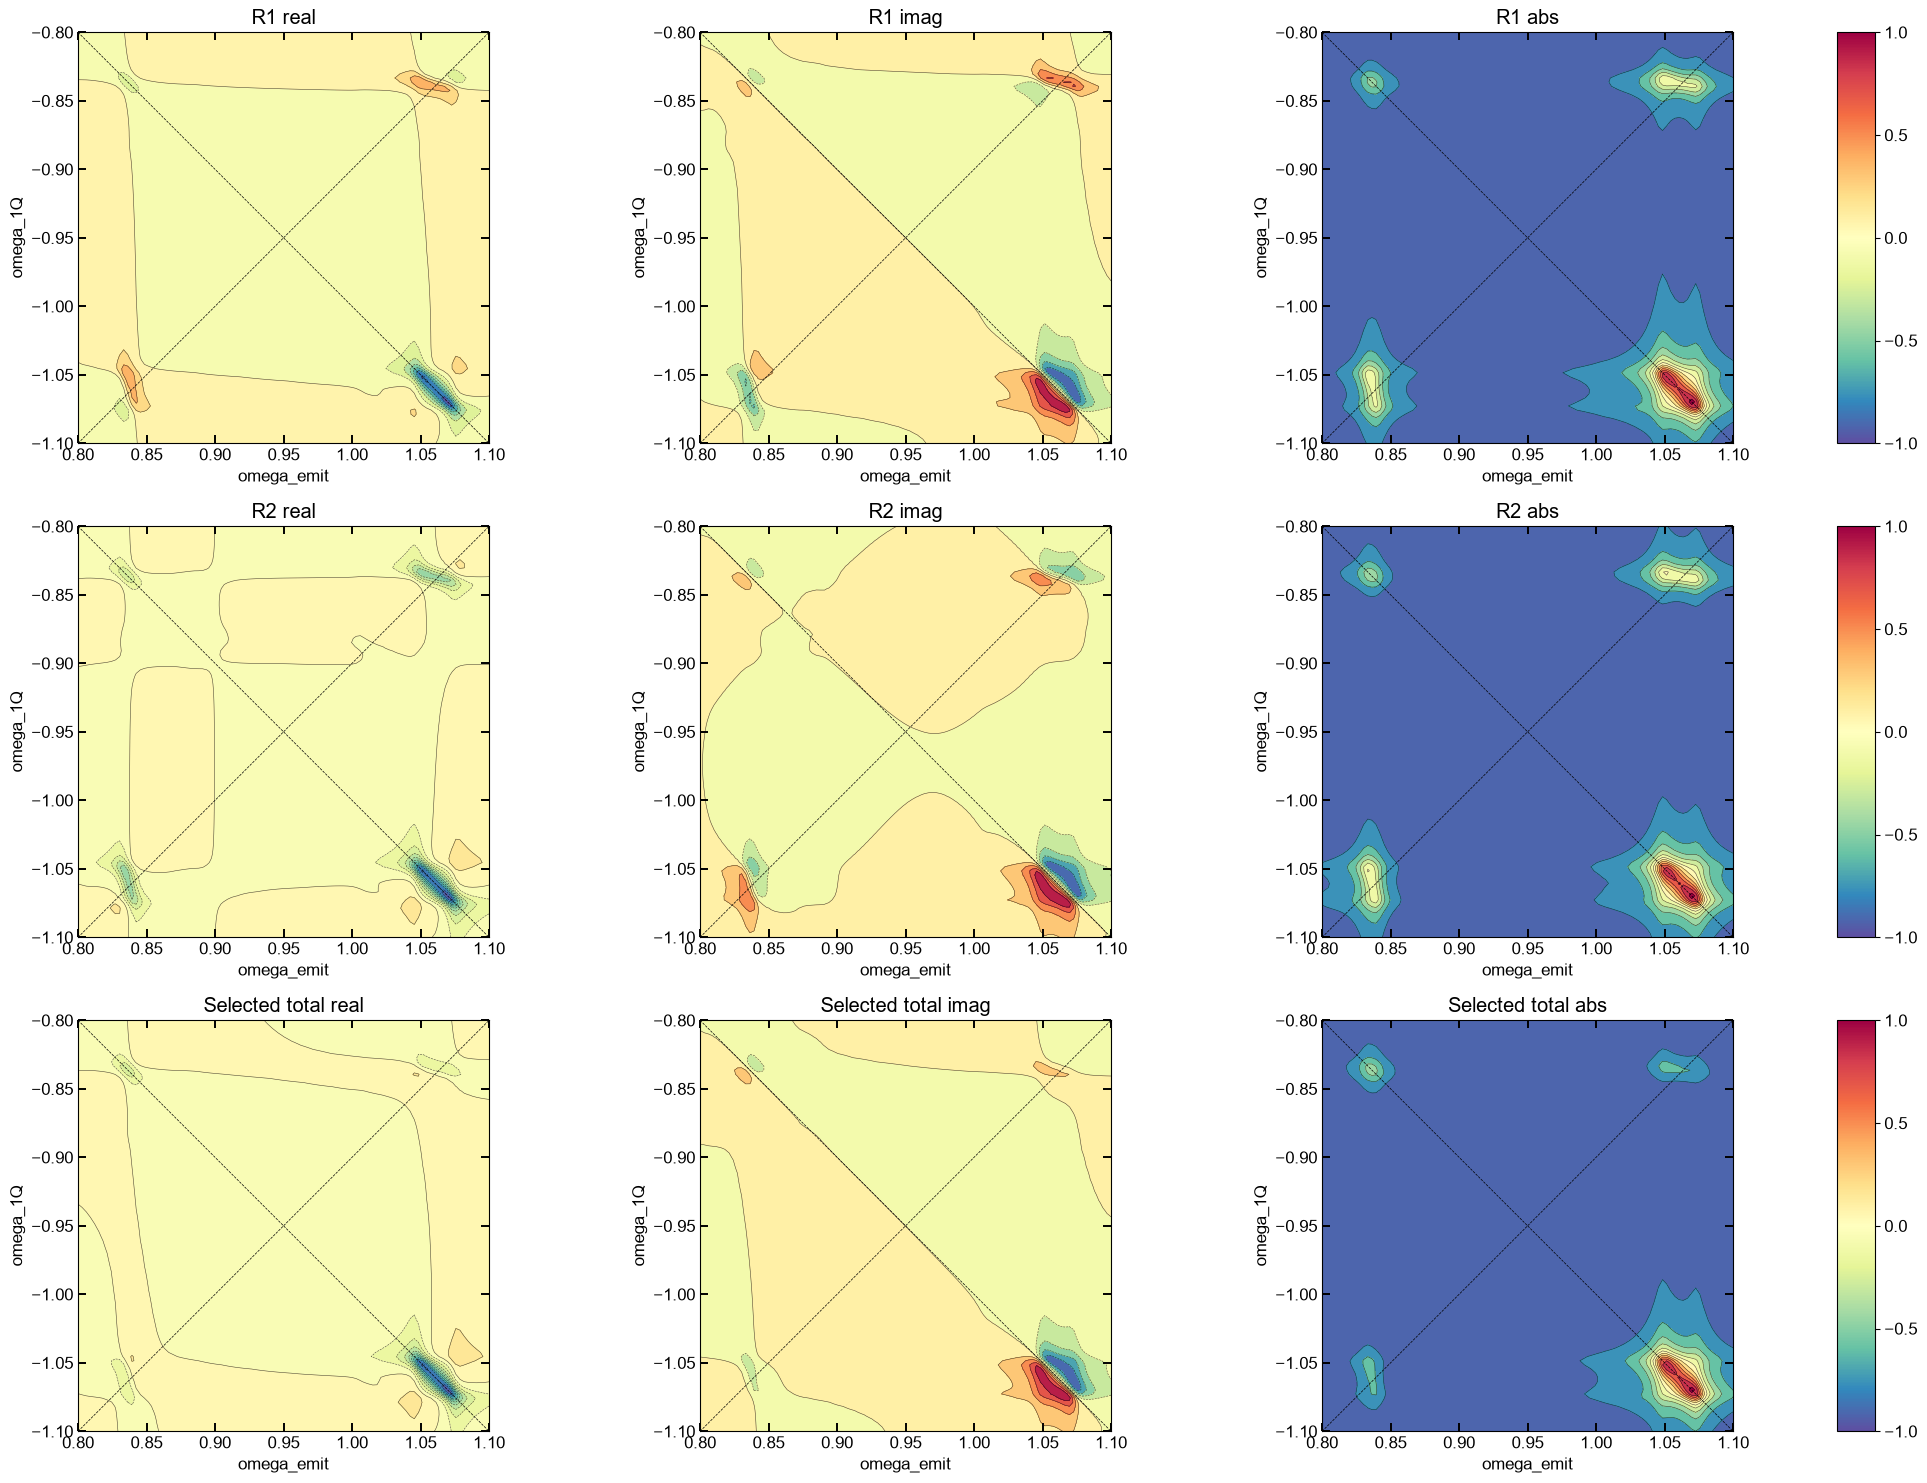

max abs: 15492.191152364363
norm: 148104.463118216


In [82]:
plotter = SpectroscopyPlotter(detection_phase=DETECTION_PHASE)
plot_index = 1

fig_none, axes_none = plotter.plot_spectrum_result_contours(
    result[plot_index],
    spectra="pathways",
    names=["R1", "R2"],
    totals="selected",
    normalization="none",
    color_map="Spectral_r",
    levels=12,
    show=True,
)

fig_panel, axes_panel = plotter.plot_spectrum_result_contours(
    result[plot_index],
    spectra="pathways",
    names=["R1", "R2"],
    totals="selected",
    normalization="panel",
    color_map="Spectral_r",
    levels=12,
    show=True,
)

total = result[plot_index].pathways["R1"] + result[plot_index].pathways["R2"]
print("max abs:", np.max(np.abs(total)))
print("norm:", np.linalg.norm(total))


## Extract scalar observables


In [83]:
# Edit these windows before extracting the observables.
# Bounds follow the result axes: omega1 is the coherence axis and omega3 is the emission axis.
CROSS_WINDOW_DOWN = {
    "omega1": (-1.085, -1.045),
    "omega3": (0.80, 0.85),
}

CROSS_WINDOW_UP = {
    "omega1": (-0.85, -0.80),
    "omega3": (1.0, 1.1),
}

DIAG_WINDOW = {
    "omega1": (-1.085, -1.045),
    "omega3": (1.045, 1.095),
}

# Local feature centers used for cut-based scalar observables.
# For rephasing: diagonal has negative slope, off-diagonal has positive slope.
FEATURE_DOWN_LEFT = {"omega1": -1.06, "omega3": 0.83}
FEATURE_UP_RIGHT = {"omega1": -0.83, "omega3": 1.06}
FEATURE_DOWN_RIGHT = {"omega1": -1.06, "omega3": 1.06}
FEATURE_UP_LEFT = {"omega1": -0.83, "omega3": 0.83}

FEATURE_SPECS = {
    "down_left": {
        "center": FEATURE_DOWN_LEFT,
        "half_length": 0.04,
        "width": 0.01,
        "quadrant": "rephasing",
    },
    "up_right": {
        "center": FEATURE_UP_RIGHT,
        "half_length": 0.04,
        "width": 0.01,
        "quadrant": "rephasing",
    },
    "down_right": {
        "center": FEATURE_DOWN_RIGHT,
        "half_length": 0.04,
        "width": 0.01,
        "quadrant": "rephasing",
    },
    "up_left": {
        "center": FEATURE_UP_LEFT,
        "half_length": 0.04,
        "width": 0.01,
        "quadrant": "rephasing",
    },
}

observables = extract_spectrum_observables(
    result[plot_index],
    spectra="pathways",
    names=["R1", "R2"],
    detection_phase=DETECTION_PHASE,
    cross_window=CROSS_WINDOW_DOWN,
    diag_window=DIAG_WINDOW,
    feature_specs=FEATURE_SPECS,
)
observables


{'Imax': 15492.191152364363,
 'Iint': 57.37485744857299,
 'Icross': 2.672367352936417,
 'Idiag': 15.5707370442521,
 'Rcross': 0.1716275437277977,
 'IR1': 39.88448754025854,
 'IR2': 33.183591557058534,
 'omega1_star': -1.0696969696969698,
 'omega3_star': 1.0696969696969698,
 'cross_window': {'omega_1Q': (-1.085, -1.045), 'omega_emit': (0.8, 0.85)},
 'diag_window': {'omega_1Q': (-1.085, -1.045), 'omega_emit': (1.045, 1.095)},
 'down_left_diagonal_Iint': 1.4558327008139715,
 'down_left_diagonal_Iabsint': 1.4558327008139715,
 'down_left_diagonal_Imax': 0.08464424099861054,
 'down_left_diagonal_coord_star': 0.9502525252525253,
 'down_left_diagonal_omega1_star': -1.0652525252525253,
 'down_left_diagonal_omega3_star': 0.8352525252525252,
 'down_left_diagonal_center_energy_eV': 0.9450000000000001,
 'down_left_diagonal_center': {'omega_1Q': -1.06, 'omega_emit': 0.83},
 'down_left_diagonal_half_length': 0.04,
 'down_left_diagonal_width': 0.01,
 'down_left_off_diagonal_Iint': 1.2062627909488295,


## Plot one-dimensional cuts


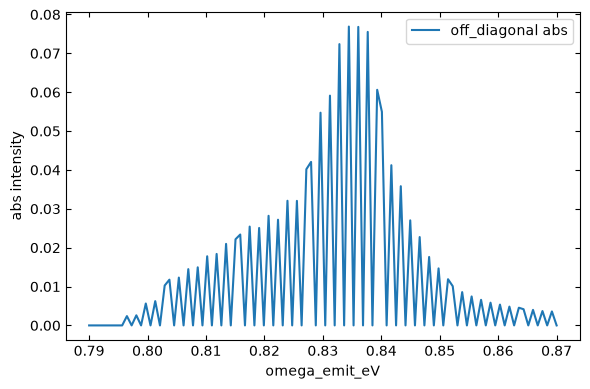

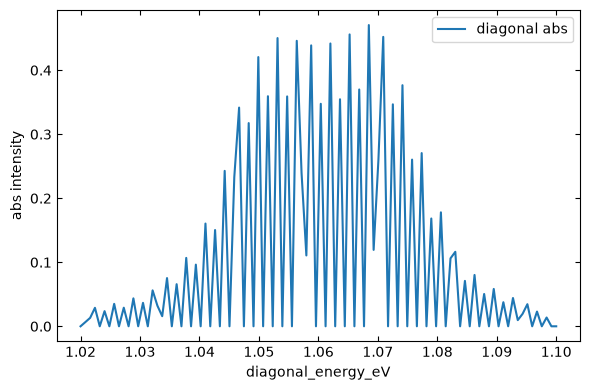

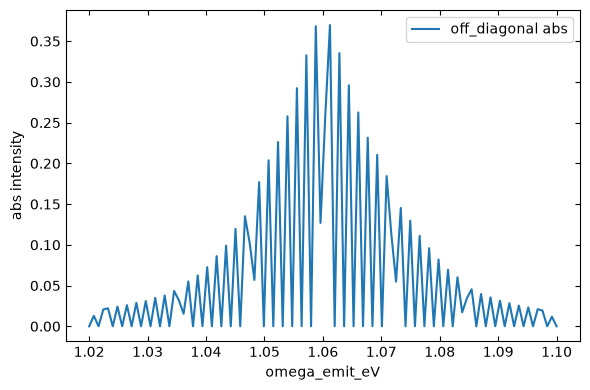

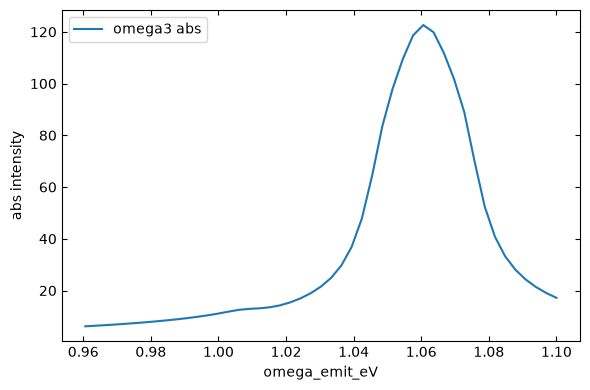

In [84]:
# Local 1D cuts through selected feature centers.
fig_cross_1d, ax_cross_1d, cross_profile = plotter.plot_spectrum_profile(
    result[plot_index],
    spectra="pathways",
    names=["R1", "R2"],
    quantity="abs",
    cut="off_diagonal",
    center=FEATURE_DOWN_LEFT,
    half_length=0.04,
    width=0.01,
    quadrant="rephasing",
    show=True,
)

fig_diag_1d, ax_diag_1d, diag_profile = plotter.plot_spectrum_profile(
    result[plot_index],
    spectra="pathways",
    names=["R1", "R2"],
    quantity="abs",
    cut="diagonal",
    center=FEATURE_DOWN_RIGHT,
    half_length=0.04,
    width=0.01,
    quadrant="rephasing",
    show=True,
)

fig_offdiag_1d, ax_offdiag_1d, offdiag_profile = plotter.plot_spectrum_profile(
    result[plot_index],
    spectra="pathways",
    names=["R1", "R2"],
    quantity="abs",
    cut="off_diagonal",
    center=FEATURE_DOWN_RIGHT,
    half_length=0.04,
    width=0.01,
    quadrant="rephasing",
    show=True,
)


fig, ax, profile_w3 = plotter.plot_spectrum_profile(
    result[plot_index],
    spectra="pathways",
    names=["R1", "R2"],
    quantity="abs",
    cut="omega3",
    center={"omega1": -1.06, "omega3": 1.06},
    half_length=0.1,
    width=0.01,
    show=True,
)



## Optional save bundle


In [85]:
SAVE_RUN = False

if SAVE_RUN:
    run_id = make_run_id(
        step=20,
        scan_name="manual",
        index=plot_index,
        scenario="k_model",
        values={
            "gQmod": model_params["g_Q_k_modulation"],
            "Nk": len(meta["k_array"]),
            "t2": spectrum_delays[plot_index]["t2"],
        },
    )
    mechanism_note = build_mechanism_note(model_params, meta)
    save_paths = save_spectrum_bundle(
        result[plot_index],
        output_root=RESULT_ROOT,
        run_id=run_id,
        params={
            "source_notebook": str(PROJECT_ROOT / "SOC_workbench_k_model.ipynb"),
            "model_params": model_params,
            "solver_params": solver_params,
            "spectrum_params": {
                "N_w": N_w,
                "omega1_rephasing": omega1_rephasing,
                "omega1_unrephasing": omega1_unrephasing,
                "omega3": omega3,
                "detection_phase": DETECTION_PHASE,
            },
            "delays": spectrum_delays[plot_index],
            "meta": meta,
        },
        observables=observables,
        note=mechanism_note,
        figures={
            "pathways_none": fig_none,
            "pathways_panel": fig_panel,
            "cross_profile_abs": fig_cross_1d,
            "diagonal_profile_abs": fig_diag_1d,
            "off_diagonal_profile_abs": fig_offdiag_1d,
        },
    )
    save_paths
